#IMPORTING LIBRARIES



In [ ]:
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Dropout,
    LSTM,
    Bidirectional
)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
import pandas as pd

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
print(train_df.shape)
print(test_df.shape)

(7352, 563)
(2947, 563)


In [ ]:
print(train_df.head())

print(train_df.shape)
print(test_df.shape)

print(train_df.columns)

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyr

In [ ]:
print(X_train.shape)
print(X_test.shape)

(7352, 562)
(2947, 562)


#spliiting my data

In [ ]:
X_train = train_df.drop("Activity", axis=1)

y_train = train_df["Activity"]

X_test = test_df.drop("Activity", axis=1)

y_test = test_df["Activity"]

Label encoding my target

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)

y_test = encoder.transform(y_test)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [ ]:
X_train = X_train.to_numpy()

X_test = X_test.to_numpy()

X_train = X_train.reshape(
    X_train.shape[0],
    2,
    281
)

X_test = X_test.reshape(
    X_test.shape[0],
    2,
    281
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(7352, 2, 281)
(2947, 2, 281)


In [ ]:
print(y_train.shape)

(7352, 6)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Dropout
)

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        64,
        input_shape=(2,281),
        activation='tanh'
    )
)

rnn_model.add(Dropout(0.3))

rnn_model.add(Dense(32, activation='relu'))

rnn_model.add(Dense(
    y_train.shape[1],
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = rnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5431 - loss: 1.0701 - val_accuracy: 0.8178 - val_loss: 0.5714
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8279 - loss: 0.4120 - val_accuracy: 0.9211 - val_loss: 0.2893
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9012 - loss: 0.2539 - val_accuracy: 0.9198 - val_loss: 0.1959
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9308 - loss: 0.1771 - val_accuracy: 0.9449 - val_loss: 0.1551
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9531 - loss: 0.1291 - val_accuracy: 0.9436 - val_loss: 0.1585
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9548 - loss: 0.1160 - val_accuracy: 0.9293 - val_loss: 0.2009
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9691 - loss: 0.0889 - val_accuracy: 0.9456 - val_loss: 0.1452
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9745 - loss: 0.0728 - val_accuracy: 0.9449 - val_loss

In [ ]:
rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        22,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,268 (286.21 KB)

 Trainable params: 24,422 (95.40 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 48,846 (190.81 KB)

In [ ]:
loss, accuracy = rnn_model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9427 - loss: 0.1624
Accuracy: 0.9426535367965698


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = rnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred_classes
    )
)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.89      0.92      0.90       491
           2       0.92      0.90      0.91       532
           3       0.99      0.95      0.97       496
           4       0.96      0.90      0.93       420
           5       0.90      0.99      0.94       471

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



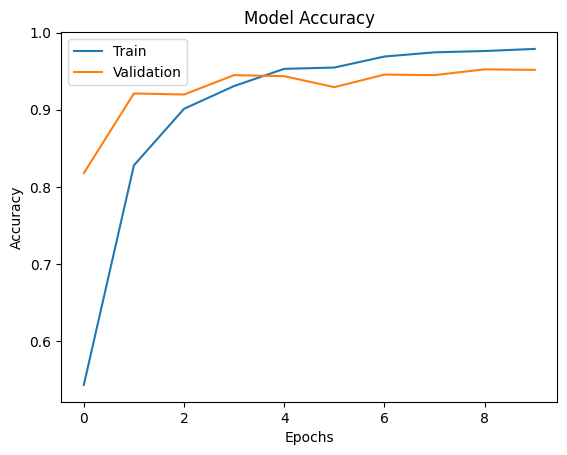

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    SimpleRNN,
    Bidirectional,
    Dense,
    Dropout
)

birnn_model = Sequential()

birnn_model.add(

    Bidirectional(SimpleRNN(64),input_shape=(2,281))
)

birnn_model.add(Dropout(0.3))
birnn_model.add(Dense(
    32,
    activation='relu'
))
birnn_model.add(Dense(
    y_train.shape[1],
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
birnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_bi = birnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6553 - loss: 0.8136 - val_accuracy: 0.8872 - val_loss: 0.3684
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8818 - loss: 0.2974 - val_accuracy: 0.9307 - val_loss: 0.2245
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9169 - loss: 0.2052 - val_accuracy: 0.9334 - val_loss: 0.1985
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9442 - loss: 0.1445 - val_accuracy: 0.9477 - val_loss: 0.1363
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9463 - loss: 0.1358 - val_accuracy: 0.9483 - val_loss: 0.1184
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9614 - loss: 0.0985 - val_accuracy: 0.9504 - val_loss: 0.1179
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9653 - loss: 0.0869 - val_accuracy: 0.9334 - val_loss: 0.1899
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9699 - loss: 0.0766 - val_accuracy: 0.9517 - val_lo

In [ ]:
birnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        44,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,844 (569.71 KB)

 Trainable params: 48,614 (189.90 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 97,230 (379.81 KB)

In [ ]:
loss, accuracy = birnn_model.evaluate(
    X_test,
    y_test
)

print("BiRNN Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9515 - loss: 0.1464
BiRNN Accuracy: 0.9514760971069336


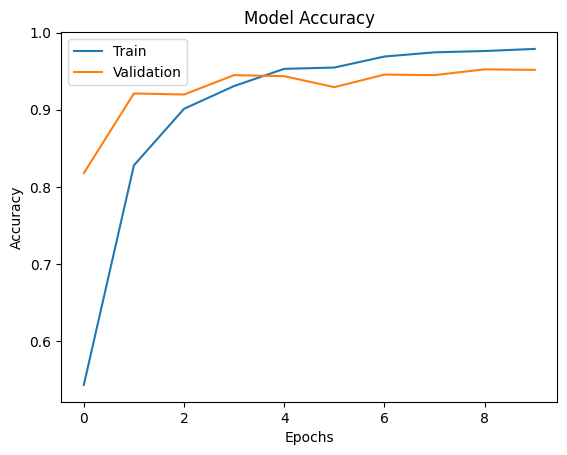

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
import pandas as pd

acc_df = pd.read_csv("/content/Accelerometer.csv")

gyro_df = pd.read_csv("/content/Gyroscope.csv")

lin_df = pd.read_csv("/content/Linear Accelerometer.csv")

In [ ]:
print(acc_df.columns)

print(gyro_df.columns)

print(lin_df.columns)

Index(['Time (s)', 'X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)'], dtype='object')
Index(['Time (s)', 'X (rad/s)', 'Y (rad/s)', 'Z (rad/s)'], dtype='object')
Index(['Time (s)', 'X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)'], dtype='object')


In [ ]:
acc_df = acc_df.rename(columns={
    'x':'accX',
    'y':'accY',
    'z':'accZ'
})

In [ ]:
gyro_df = gyro_df.rename(columns={
    'x':'gyroX',
    'y':'gyroY',
    'z':'gyroZ'
})

In [ ]:
lin_df = lin_df.rename(columns={
    'x':'linX',
    'y':'linY',
    'z':'linZ'
})

In [ ]:
acc_data = acc_df[
    ['X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)']
]

acc_data.columns = ['accX', 'accY', 'accZ']

In [ ]:
gyro_data = gyro_df[
    ['X (rad/s)', 'Y (rad/s)', 'Z (rad/s)']
]

gyro_data.columns = ['gyroX', 'gyroY', 'gyroZ']

In [ ]:
lin_data = lin_df[
    ['X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)']
]

lin_data.columns = ['linX', 'linY', 'linZ']

In [ ]:
final_df = pd.concat(
    [acc_data, gyro_data, lin_data],
    axis=1
)

In [ ]:
print(final_df.head())

       accX      accY      accZ     gyroX     gyroY     gyroZ      linX  \
0 -0.174537  0.605641  8.247250  0.275426  0.645964 -0.014506  0.385541   
1  0.340093  0.358804  9.836794 -0.004297 -0.012052  0.000042  0.041472   
2  0.369881  0.455802  9.739347  0.002637 -0.000310 -0.001144  0.062623   
3  0.345482  0.354912  9.758657  0.000745  0.002709 -0.000029  0.066897   
4  0.359552  0.380658  9.846823  0.001901 -0.001917  0.000041  0.041902   

       linY      linZ  
0 -0.110625  0.643873  
1  0.003912 -0.096400  
2 -0.079588 -0.001099  
3  0.058857  0.028914  
4  0.018248 -0.106967  


In [ ]:
X = final_df.to_numpy()

In [ ]:
flat_data = X

In [ ]:
flat_data = flat_data.flatten()[:562]

In [ ]:
input_data = flat_data.reshape(
    1,
    2,
    281
)

In [ ]:
print(input_data.shape)

(1, 2, 281)


In [ ]:
model = birnn_model

In [ ]:
predictions = model.predict(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


In [ ]:
import numpy as np

predicted_class = np.argmax(predictions)

print(predicted_class)

0


In [ ]:
labels = {
    0: "Walking",
    1: "Running",
    2: "Sitting",
    3: "Standing"
}

print(labels[predicted_class])

Walking
